In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 



In [3]:
data = pd.read_csv("pca Wine clustering.csv")
data.head(4)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480


In [4]:
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()
data_scaled = standard.fit_transform(data)



In [5]:
data_scaled  # data is scalled now 
data_scaled_df = pd.DataFrame(data_scaled, columns=data.columns)
data_scaled_df.head(2)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242


In [6]:
from sklearn.decomposition import PCA


In [7]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(data_scaled_df)

print("Shape before PCA:", data_scaled_df.shape)
print("Shape after PCA:", X_pca.shape)

Shape before PCA: (178, 13)
Shape after PCA: (178, 5)


In [ ]:
variance = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:", variance*100)
print("Total Information Retained:", sum(variance)*100)   #These numbers tell you how much detail you lost during that compression.
# thus total 85 percent information is reterained after PCA transformation.


Explained Variance Ratio: [36.1988481  19.20749026 11.12363054  7.06903018  6.56329368]
Total Information Retained: 80.16229275554787


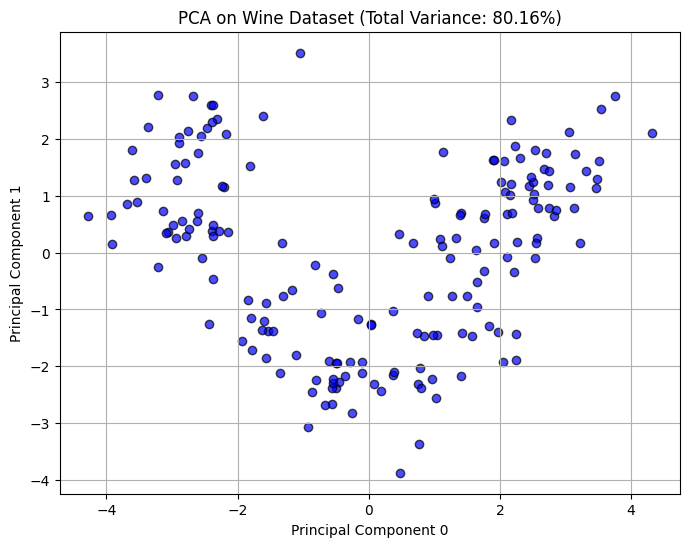

In [9]:
plt.figure(figsize=(8, 6))

# ONLY pass the first two columns: PC0 as x, PC1 as y
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', edgecolors='k', alpha=0.7)

plt.xlabel("Principal Component 0")
plt.ylabel("Principal Component 1")
plt.title(f"PCA on Wine Dataset (Total Variance: {sum(variance)*100:.2f}%)")
plt.grid(True)
plt.show()

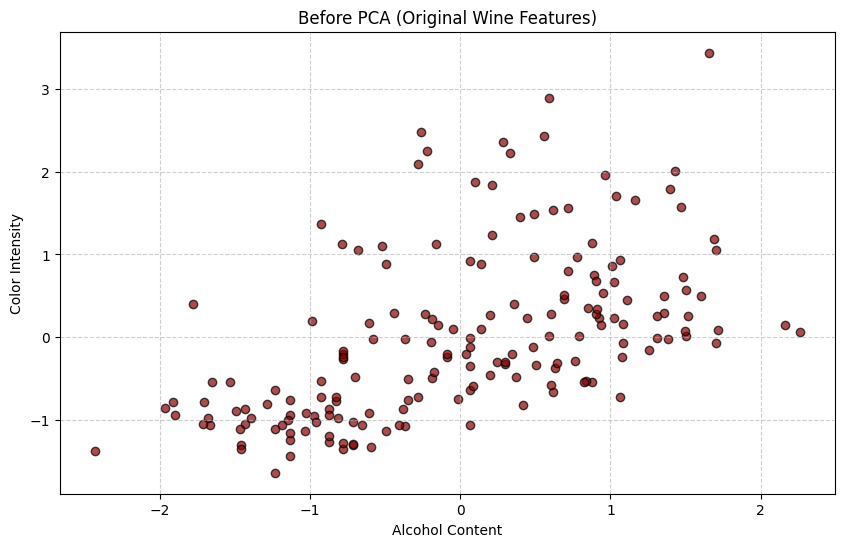

In [ ]:
plt.figure(figsize=(10, 6))

# 2. Draw the scatter plot using two original columns
plt.scatter(data_scaled_df['Alcohol'], data_scaled_df['Color_Intensity'], color='darkred', edgecolors='k', alpha=0.7)

# 3. Add labels and title
plt.xlabel("Alcohol Content")
plt.ylabel("Color Intensity")
plt.title("Before PCA (Original Wine Features)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

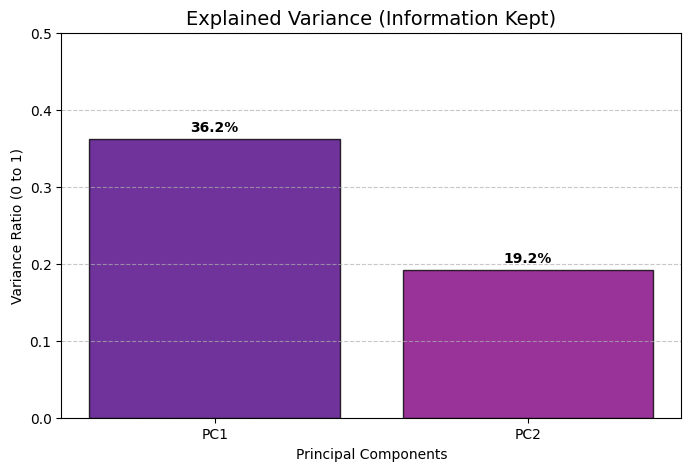

In [11]:
import matplotlib.pyplot as plt

# 1. Create labels for the first two components
labels = ['PC1', 'PC2']

variance_values = pca.explained_variance_ratio_[:2]

plt.figure(figsize=(8, 5))
plt.bar(labels, variance_values, color=['#4B0082', '#800080'], edgecolor='black', alpha=0.8)

# Adding the percentage text on top of the bars
for i, val in enumerate(variance_values):
    plt.text(i, val + 0.01, f'{val*100:.1f}%', ha='center', fontweight='bold')

plt.title("Explained Variance (Information Kept)", fontsize=14)
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio (0 to 1)")
plt.ylim(0, 0.5) # Setting limit slightly higher than your max (0.36)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()